# Slocum L0 exploration — first pass

Quick, **L0-only** look at a mission, before any processing decisions are
made. No L1/L2 needed — just the raw decoded archive
(`slocum-process-mission <N> --from-ogdb --steps l0`).

Answers the three things you need before setting `processing.l1_time_range`
(and `unused_sensors`) in `deployment.yml` — see
`docs/user-guide/processing-a-mission.md` step 3:

1. **Track** — where did the glider actually go (`m_lat`/`m_lon`)?
2. **Depth vs time** — when did real diving start/stop
   (`m_present_time` vs `m_depth`, the flight side — present from the very
   first file, unlike the science stream)?
3. **Science channels** — which `sci_*` sensors actually logged data, over
   what range, and for how much of the deployment?

For everything past this — L1/L2, T-S, gridded sections, interactive views
— use `data_exploration.ipynb`.


## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pyglider.utils import nmea2deg   # Slocum ddmm.mmmm -> decimal degrees

plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_rows", None)      # never truncate the science-channel table
pd.set_option("display.max_colwidth", None)


## 1. Load L0

In [2]:
MISSION = 12                 # mission number, or a python/missions/ dir prefix ("002")

DATA_ROOT = Path("/Data/gfi/projects/slocum/data/delayed")

_token = f"{int(MISSION):03d}" if str(MISSION).isdigit() else str(MISSION)
_matches = [d for d in sorted(DATA_ROOT.glob(f"{_token}*")) if d.is_dir()]
assert len(_matches) == 1, f"expected one folder for {_token!r}, found {[d.name for d in _matches]}"
deployment_dir = _matches[0]
name = deployment_dir.name

l0_file = deployment_dir / "pyglider" / "L0" / f"{name}_L0.nc"
assert l0_file.is_file(), (
    f"no L0 file at {l0_file} -- run "
    f"`slocum-process-mission {MISSION} --from-ogdb --steps l0` first"
)

l0 = xr.open_dataset(l0_file)
t_all = pd.to_datetime(l0["time"].values)
print(name)
print(f"L0: {dict(l0.sizes)} samples, {t_all.min()} -> {t_all.max()}  "
      f"({t_all.max() - t_all.min()})")


012-freyja_naco_porsangerfjorden_jun2014
L0: {'time': 86221} samples, 2014-06-08 14:51:58.526764032 -> 2014-06-24 18:27:17.662262016  (16 days 03:35:19.135497984)


In [4]:
df = l0.to_dataframe() 
print(df.columns)
#df[["m_depth", "m_heading", "m_roll", "m_pitch", "m_battpos"]].style.set_sticky(axis="index")


Index(['c_wpt_lat', 'c_wpt_lon', 'm_ballast_pumped', 'm_battery', 'm_depth',
       'm_final_water_vx', 'm_final_water_vy', 'm_gps_lat', 'm_gps_lon',
       'm_heading', 'm_pitch', 'm_present_time', 'm_water_vx', 'm_water_vy',
       'sci_ctd41cp_timestamp', 'sci_flntu_chlor_units',
       'sci_flntu_turb_units', 'sci_m_present_time', 'sci_water_cond',
       'sci_water_pressure', 'sci_water_temp', 'trajectory'],
      dtype='str')


In [5]:
def variable_summary(ds, prefix="sci_"):
    t = ds["time"].values
    rows = []
    for name in ds.data_vars:
        da = ds[name]
        if "time" not in da.dims or (prefix and not name.startswith(prefix)):
            continue
        vals = da.values
        valid = ~np.isnan(vals) if np.issubdtype(vals.dtype, np.floating) else np.ones(len(vals), bool)
        n = int(valid.sum())
        if n:
            vt = t[valid]
            first, last = vt.min(), vt.max()
            interval_s = (np.median(np.diff(vt)) / np.timedelta64(1, "s")) if n > 1 else np.nan
        else:
            first = last = pd.NaT
            interval_s = np.nan
        rows.append({
            "variable": name,
            "long_name": da.attrs.get("long_name", ""),
            "units": da.attrs.get("units", ""),
            "n_obs": n,
            "coverage_%": round(100 * n / len(vals), 1),
            "first_time": first,
            "last_time": last,
            "median_interval_s": round(interval_s, 1) if not np.isnan(interval_s) else np.nan,
        })
    return pd.DataFrame(rows).sort_values("variable").reset_index(drop=True)

summary = variable_summary(l0)
summary

,variable,long_name,units,n_obs,coverage_%,first_time,last_time,median_interval_s
0,sci_ctd41cp_timestamp,,,4,0.0,2014-06-15 23:36:04.978851328,2014-06-24 13:01:58.838043136,16243.3
1,sci_flntu_chlor_units,,,11443,13.3,2014-06-08 14:53:53.664337152,2014-06-24 18:24:16.762542848,61.0
2,sci_flntu_turb_units,,,11443,13.3,2014-06-08 14:53:53.664337152,2014-06-24 18:24:16.762542848,61.0
3,sci_m_present_time,,,22915,26.6,2014-06-08 14:53:53.664337152,2014-06-24 18:24:27.971679744,13.4
4,sci_water_cond,,,11380,13.2,2014-06-08 14:54:01.857299712,2014-06-24 18:24:27.971679744,61.0
5,sci_water_pressure,,,11380,13.2,2014-06-08 14:54:01.857299712,2014-06-24 18:24:27.971679744,61.0
6,sci_water_temp,,,11380,13.2,2014-06-08 14:54:01.857299712,2014-06-24 18:24:27.971679744,61.0


In [23]:
print(l0["time"])
l0.dims
l0.coords                 # coordinate variables (things indexed by a dim, e.g. time, depth)
l0.data_vars               # the actual measured/derived variables (temperature, salinity, ...)
l0.attrs   
l0["time"].dtype
print(l0["time"].attrs.get("units")   )      
print(l0)


<xarray.DataArray 'time' (time: 32099)> Size: 257kB
array(['2012-03-12T08:46:37.420044032', '2012-03-12T08:47:43.365112320',
       '2012-03-12T08:48:16.072601344', ..., '2012-06-09T12:45:28.459777792',
       '2012-06-09T12:45:47.229461760', '2012-06-09T12:46:15.315795968'],
      shape=(32099,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 257kB 2012-03-12T08:46:37.420044032 ... 20...
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T
None
<xarray.Dataset> Size: 7MB
Dimensions:                          (time: 32099)
Coordinates:
  * time                             (time) datetime64[ns] 257kB 2012-03-12T0...
Data variables: (12/27)
    c_wpt_lat                        (time) float64 257kB ...
    c_wpt_lon                        (time) float64 257kB ...
    m_altitude                       (time) float64 257kB ...
    m_battery                        (time) float64 257kB ...
    m_battpos                        (time) float6

## 2. Track (`m_lat` / `m_lon`)

/tmp/ipykernel_20411/1576208522.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cb.ax.set_yticklabels([pd.Timestamp(v).strftime("%m-%d") for v in cb.get_ticks()])


[Text(1, 1.4022e+18, '06-08'),
 Text(1, 1.4024e+18, '06-10'),
 Text(1, 1.4026e+18, '06-12'),
 Text(1, 1.4028e+18, '06-15'),
 Text(1, 1.403e+18, '06-17'),
 Text(1, 1.4032e+18, '06-19'),
 Text(1, 1.4034e+18, '06-22'),
 Text(1, 1.4036e+18, '06-24'),
 Text(1, 1.4038e+18, '06-26')]

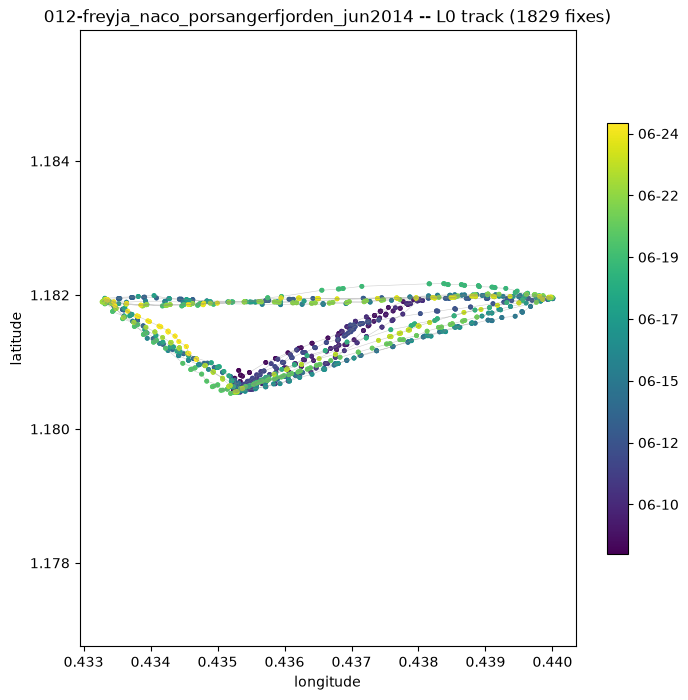

In [7]:
# Slocum m_lat/m_lon are raw NMEA ddmm.mmmm, NOT decimal degrees --
# e.g. 6015.234 = 60 deg 15.234' = 60.2539 deg. Convert before plotting;
# pyglider's own L1 build does the same conversion internally for its
# latitude/longitude, but L0 keeps the raw sensor value untouched.
lat = nmea2deg(l0["m_gps_lat"].values)
lon = nmea2deg(l0["m_gps_lon"].values)
t = pd.to_datetime(l0["time"].values)
ok = np.isfinite(lat) & np.isfinite(lon)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(lon[ok], lat[ok], c=t[ok].astype("int64"), s=6, cmap="viridis")
ax.plot(lon[ok], lat[ok], "-", lw=0.4, alpha=0.4, color="grey")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_aspect("equal", "datalim")
ax.set_title(f"{name} -- L0 track ({int(ok.sum())} fixes)")
cb = fig.colorbar(sc, ax=ax, shrink=0.7)
cb.ax.set_yticklabels([pd.Timestamp(v).strftime("%m-%d") for v in cb.get_ticks()])


## 3. Depth vs time — suggest a start/stop window

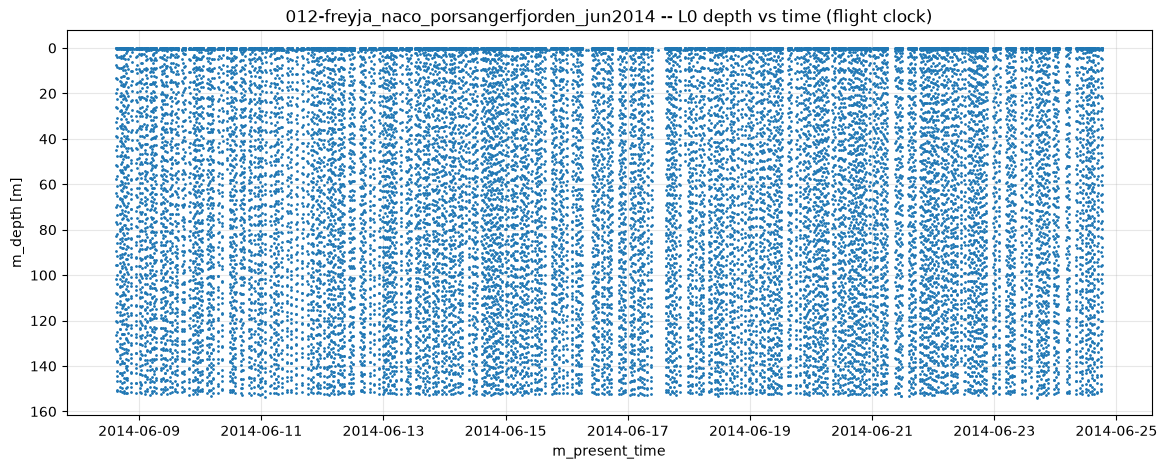

In [8]:
# m_present_time is the flight computer's own clock, logged as raw Unix
# epoch seconds (not auto-decoded like the L0 `time` coordinate) -- convert
# with unit="s". Using the raw sensor pair (not L0's merged `time` axis)
# is deliberate: it's exactly what m_depth was actually logged against.
t_depth = pd.to_datetime(l0["m_present_time"].values, unit="s")
z = l0["m_depth"].values
ok = np.isfinite(t_depth) & np.isfinite(z)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_depth[ok], z[ok], ".", ms=2)
ax.invert_yaxis()
ax.set_xlabel("m_present_time"); ax.set_ylabel("m_depth [m]")
ax.set_title(f"{name} -- L0 depth vs time (flight clock)")
ax.grid(alpha=0.3)


In [9]:
# Heuristic first guess for processing.l1_time_range: a day only counts as
# "diving" if it has enough samples AND real depth range -- filters out
# bench tests / a surface checkout where m_depth barely moves. Diving days
# are then grouped into episodes (allowing small gaps -- a glider can sit
# at the surface a day or two mid-deployment for comms/GPS); the longest
# episode is the suggestion, others are reported separately so an isolated
# pre-deployment trial (see mission 002) doesn't get bridged into it.
#
# This is a depth-only heuristic, not a verdict on science-data quality --
# always cross-check against the plot above and the science-channel plots
# below. (Mission 002's FLNTU is the cautionary tale the other way: OGDB
# assigning a sensor to a mission doesn't mean it was switched on -- the
# data is what decides, not the config.)
MIN_SAMPLES_PER_DAY = 100
MIN_DEPTH_RANGE_M = 5.0
MAX_GAP_DAYS = 2   # merge diving days into one episode across gaps this short

s = pd.Series(z[ok], index=t_depth[ok]).sort_index()
daily = s.resample("1D").agg(["count", "min", "max"])
daily.columns = ["n", "zmin", "zmax"]
daily["range"] = daily["zmax"] - daily["zmin"]
diving = daily[(daily["n"] >= MIN_SAMPLES_PER_DAY) & (daily["range"] >= MIN_DEPTH_RANGE_M)]

print(daily.round(1))

if diving.empty:
    print("\nno day meets the diving threshold -- lower MIN_SAMPLES_PER_DAY / "
          "MIN_DEPTH_RANGE_M and re-run")
else:
    gap = diving.index.to_series().diff() > pd.Timedelta(days=MAX_GAP_DAYS)
    episode = gap.cumsum()
    episodes = [grp.index for _, grp in diving.groupby(episode)]
    episodes.sort(key=len, reverse=True)

    def _bounds(ep):
        # ep is day-bucket midnights from resample("1D") -- .date() on those
        # would just print 00:00:00. Look up the actual first/last real
        # m_depth sample within the episode's day span instead.
        day0, day1 = ep.min(), ep.max() + pd.Timedelta(days=1)
        in_ep = (t_depth[ok] >= day0) & (t_depth[ok] < day1)
        t_in_ep = t_depth[ok][in_ep]
        return t_in_ep.min(), t_in_ep.max()

    for ep in episodes:
        tag = "longest -- suggested" if ep is episodes[0] else "separate episode"
        t0, t1 = _bounds(ep)
        print(f"\n{tag}: {t0.round('s')} .. {t1.round('s')} ({len(ep)} day(s))")

    t0, t1 = _bounds(episodes[0])
    start, end = t0.date(), (t1 + pd.Timedelta(days=1)).date()   # +1 so the last day isn't clipped
    print(f"\nexact bounds of the suggested episode: {t0.round('s')} .. {t1.round('s')}")
    print(f"suggested processing.l1_time_range (whole days): ['{start}', '{end}']")
    # l1_time_range accepts full timestamps, not just dates (_slice_time
    # passes the strings straight to np.datetime64) -- useful since the
    # first/last dives of a deployment are often junk (settling / holding
    # position at recovery). This is just the episode's own first/last
    # sample, not a "good science" boundary -- trim further by hand once
    # you've looked at the science-channel plots below.
    t0r, t1r = t0.round("s").isoformat(), t1.round("s").isoformat()
    print(f"or, to the exact sample (trim further by hand as needed): "
          f"['{t0r}', '{t1r}']")


               n  zmin   zmax  range
2014-06-08   577   0.0  152.0  152.0
2014-06-09  1639   0.0  152.7  152.7
2014-06-10  1414   0.0  153.0  153.0
2014-06-11  1196   0.0  153.7  153.7
2014-06-12  1421   0.0  152.9  152.9
2014-06-13  1736   0.0  152.9  152.9
2014-06-14  1795   0.0  152.8  152.8
2014-06-15  1651   0.0  152.6  152.6
2014-06-16  1344   0.0  152.5  152.5
2014-06-17  1247   0.0  152.9  152.9
2014-06-18  1508   0.0  153.0  153.0
2014-06-19  1534   0.0  152.9  152.9
2014-06-20  1826   0.0  152.8  152.8
2014-06-21  1580   0.0  153.2  153.2
2014-06-22  1739   0.0  152.8  152.8
2014-06-23  1377   0.0  154.1  154.1
2014-06-24  1003   0.0  152.6  152.6

longest -- suggested: 2014-06-08 14:51:59 .. 2014-06-24 18:27:13 (17 day(s))

exact bounds of the suggested episode: 2014-06-08 14:51:59 .. 2014-06-24 18:27:13
suggested processing.l1_time_range (whole days): ['2014-06-08', '2014-06-25']
or, to the exact sample (trim further by hand as needed): ['2014-06-08T14:51:59', '2014-06-24T1

## 4. Science channels

In [10]:
# Every sci_* variable that carried data in L0 -- build_l0 already drops
# any sensor that was declared in sensors.txt but never logged a finite
# value, so everything listed here logged *something*. "Some data" isn't
# the same as "data for the whole deployment window" -- check n / first /
# last against the deployment span above, and the plots below.
sci_vars = sorted(v for v in l0.data_vars
                  if v.startswith("sci_") and v != "sci_m_present_time")

rows = []
for v in sci_vars:
    x = l0[v].values
    ok_v = np.isfinite(x)
    tv = t_all[ok_v]
    rows.append({"variable": v, "n": int(ok_v.sum()),
                 "first": tv.min(), "last": tv.max(),
                 "min": np.nanmin(x), "max": np.nanmax(x)})
summary = pd.DataFrame(rows).set_index("variable")
summary


,n,first,last,min,max
variable,,,,,
sci_ctd41cp_timestamp,4,2014-06-15 23:36:04.978851328,2014-06-24 13:01:58.838043136,0.000,0.00000
sci_flntu_chlor_units,11443,2014-06-08 14:53:53.664337152,2014-06-24 18:24:16.762542848,0.000,3.52800
sci_flntu_turb_units,11443,2014-06-08 14:53:53.664337152,2014-06-24 18:24:16.762542848,0.000,11.98410
sci_water_cond,11380,2014-06-08 14:54:01.857299712,2014-06-24 18:24:27.971679744,0.000,3.58324
sci_water_pressure,11380,2014-06-08 14:54:01.857299712,2014-06-24 18:24:27.971679744,-0.008,15.67300
sci_water_temp,11380,2014-06-08 14:54:01.857299712,2014-06-24 18:24:27.971679744,0.000,8.90640


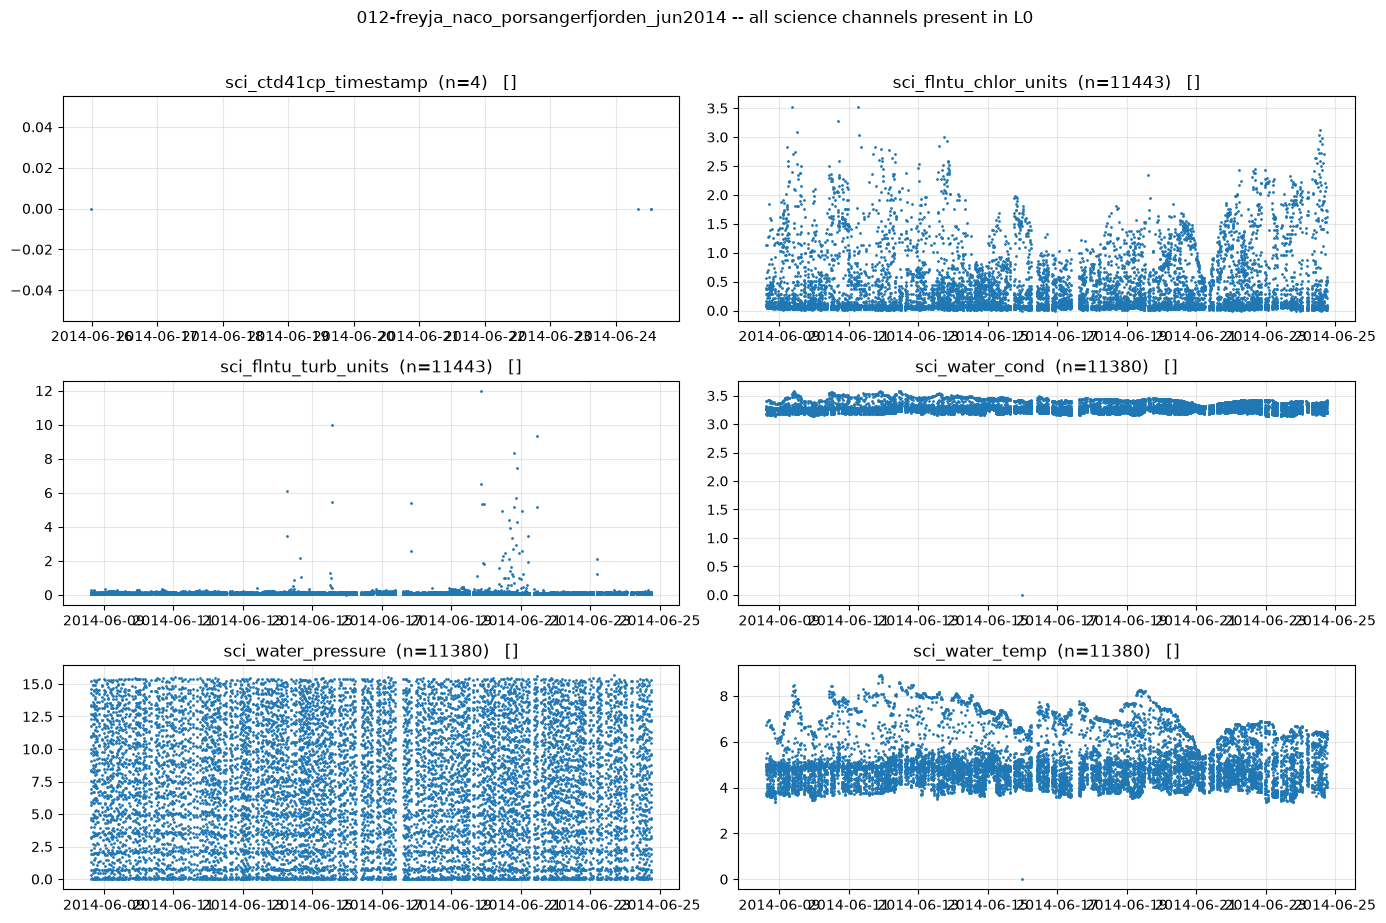

In [11]:
ncols = 2
nrows = -(-len(sci_vars) // ncols)   # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), squeeze=False)
for ax, v in zip(axes.flat, sci_vars):
    x = l0[v].values
    ok_v = np.isfinite(x)
    ax.plot(t_all[ok_v], x[ok_v], ".", ms=2)
    ax.set_title(f"{v}  (n={int(ok_v.sum())})   [{l0[v].attrs.get('units', '')}]")
    ax.grid(alpha=0.3)
for ax in axes.flat[len(sci_vars):]:
    ax.axis("off")
fig.suptitle(f"{name} -- all science channels present in L0", y=1.02)
fig.tight_layout()


In [29]:
sci_vars

['sci_ctd41cp_timestamp',
 'sci_m_present_secs_into_mission',
 'sci_water_cond',
 'sci_water_pressure',
 'sci_water_temp']

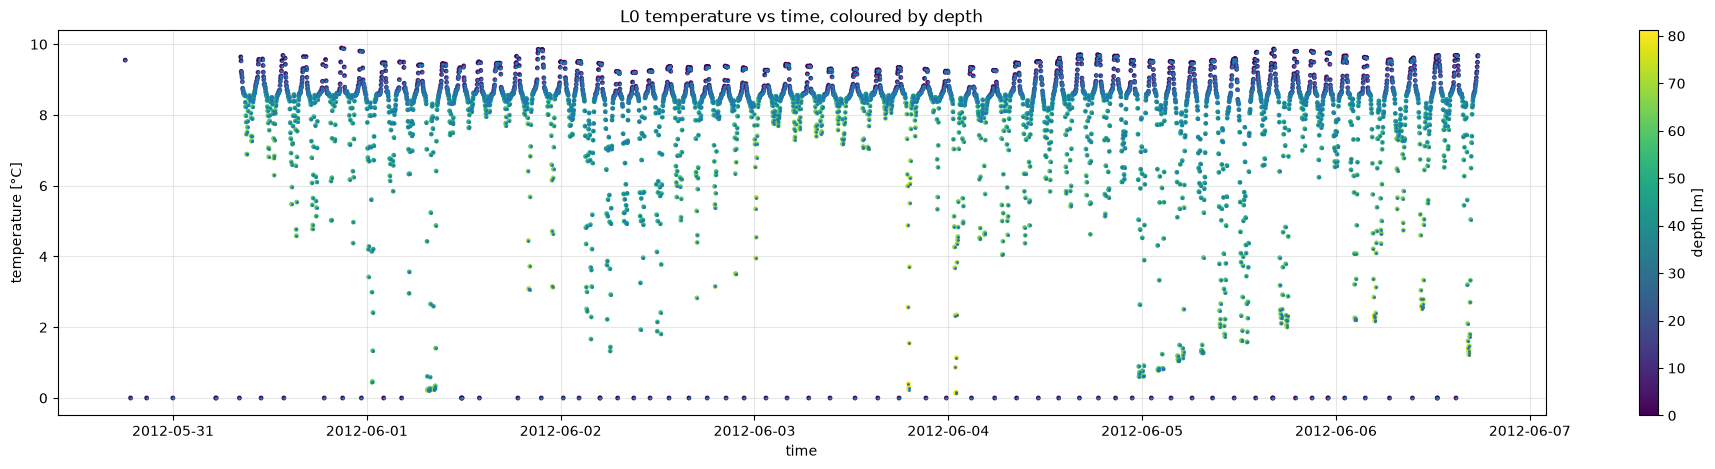

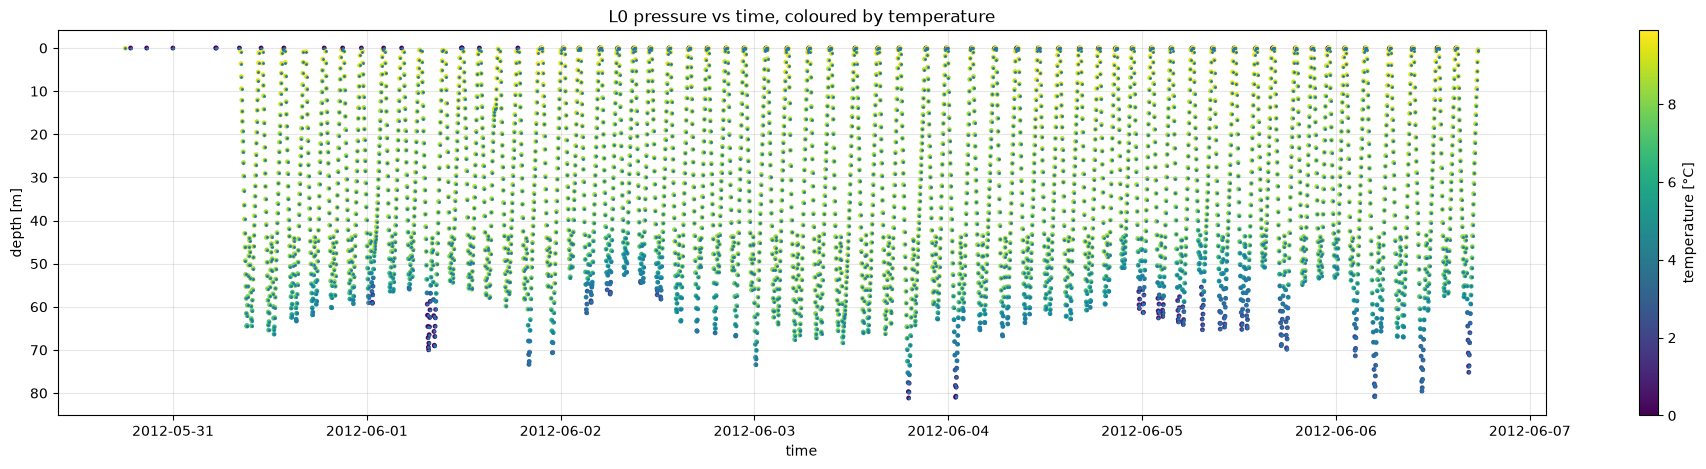

In [64]:
t0,t1 = '2012-05-30 16:56:26', '2012-06-06 17:38:00'
l0_sub = l0.sel(time=slice(t0, t1)) 


fig, ax = plt.subplots(figsize=(24, 5))
sc = ax.scatter(l0_sub["time"].values,l0_sub["sci_water_temp"].values, c=l0_sub["sci_water_pressure"].values, cmap="viridis",s=6)
ax.plot(l0_sub["time"].values,l0_sub["sci_water_temp"].values, ".", ms=2)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("depth [m]")
ax.set_xlabel("time")
ax.set_ylabel("temperature [°C]")
ax.set_title("L0 temperature vs time, coloured by depth")
ax.grid(alpha=0.3)


fig1, ax1 = plt.subplots(figsize=(24, 5))
sc = ax1.scatter(l0_sub["time"].values,l0_sub["sci_water_pressure"].values, c=l0_sub["sci_water_temp"].values, cmap="viridis",s=6)
ax1.plot(l0_sub["time"].values,l0_sub["sci_water_pressure"].values, ".", ms=2)
cb = fig1.colorbar(sc, ax=ax1)
cb.set_label("temperature [°C]")
ax1.invert_yaxis()
ax1.set_xlabel("time")
ax1.set_ylabel("depth [m]")
ax1.set_title("L0 pressure vs time, coloured by temperature")
ax1.grid(alpha=0.3)


In [61]:
l0["m_depth"].dims

('time',)

## Next

- Real diving window narrower/wider than suggested above? Set
  `processing.l1_time_range` in `deployment.yml` accordingly.
- A science channel flat/empty for (part of) the window despite OGDB
  assigning that sensor? Add it to `processing.unused_sensors` (see the
  runbook) rather than leaving a dead calibration claim in the metadata.
- Then: `slocum-process-mission <N> --from-ogdb --regenerate` to run L1/L2,
  and switch to `data_exploration.ipynb` to look at the result.
